# 디코딩 전략 실습 (vLLM): **top_p vs min_p** @ High Temperature

이 노트북은 vLLM 인퍼런스 코드 기반으로 **샘플링 디코딩 전략**을 실습합니다.  
특히 **high temperature(예: 1.4~2.0)** 환경에서,

- `top_p`만 썼을 때 출력이 얼마나 흔들리는지  
- `min_p`(minimum probability sampling)를 추가하면 **얼마나 더 로버스트**해지는지

를 **정성(샘플 비교)** + **정량(형식 준수율/JSON 파싱 성공률)** 으로 보여줍니다.

---
## 학습 목표
1. `temperature`, `top_p`, `top_k`, `min_p`가 출력에 미치는 영향을 설명할 수 있다.
2. high temperature에서 발생하는 흔한 실패(헛소리/형식 붕괴/과도한 다양성)를 관찰하고, 완화 전략을 적용한다.
3. 간단한 **평가 루프**(예: JSON 파싱/스키마 체크)로 “로버스트함”을 측정한다.

> ⚠️ vLLM은 보통 **GPU 환경**을 전제로 합니다. (Colab/T4~A100, 사내 GPU 서버 등)


## 0) 설치 & 환경 체크

- vLLM + 실험용 라이브러리를 설치합니다.
- 강의 환경에 따라 이미 설치되어 있다면 이 셀은 스킵해도 됩니다.


In [1]:

# 설치 (조용히 설치하려면 -q 옵션을 쓰세요)
# !pip -q install "vllm" pandas matplotlib jsonschema


import os, shutil, sys
os.environ["LD_LIBRARY_PATH"] = f"/opt/conda/envs/sam/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
os.environ["PATH"] = "/opt/conda/envs/sam/bin:" + os.environ["PATH"]
print("sys.executable =", sys.executable)
print("which ninja =", shutil.which("ninja"))
print("PATH =", os.environ["PATH"])

import re, json, time
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt

from vllm import LLM, SamplingParams


sys.executable = /opt/conda/envs/sam/bin/python
which ninja = /opt/conda/envs/sam/bin/ninja
PATH = /opt/conda/envs/sam/bin:/opt/conda/bin:/opt/conda/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin


/opt/conda/envs/sam/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### GPU 확인

- vLLM은 일반적으로 CUDA GPU에서 가장 잘 동작합니다.
- GPU가 없으면(혹은 제한적이면) 아래 실험은 실행이 어렵거나 매우 느릴 수 있습니다.


In [2]:

import torch

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1) 모델 로딩 (vLLM)

강의용으로는 **작은 Instruct 모델**로 시작하는 걸 추천합니다.

- 예시) `Qwen/Qwen2.5-1.5B-Instruct`, `TinyLlama/TinyLlama-1.1B-Chat-v1.0` 등
- 사내 캐시/허깅페이스 미러 환경이면 모델 다운로드가 더 빠릅니다.

아래 `MODEL_ID`만 바꿔서 사용하세요.


In [3]:
# export LD_LIBRARY_PATH=/opt/conda/envs/sam/lib:$LD_LIBRARY_PATH


MODEL_ID = os.getenv("MODEL_ID", "Qwen/Qwen2.5-1.5B-Instruct")

# GPU 메모리 여유가 적으면 0.7~0.85 사이로 낮추는 편이 안전합니다.
GPU_MEMORY_UTILIZATION = float(os.getenv("GPU_MEMORY_UTILIZATION", "0.85"))

llm = LLM(
    model=MODEL_ID,
    dtype="auto",
    gpu_memory_utilization=GPU_MEMORY_UTILIZATION,
    trust_remote_code=True,
)

print("Loaded:", MODEL_ID)


INFO 04-17 00:53:40 [utils.py:238] non-default args: {'trust_remote_code': True, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-1.5B-Instruct'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 04-17 00:53:42 [model.py:531] Resolved architecture: Qwen2ForCausalLM
WARNING 04-17 00:53:42 [model.py:1839] Your device 'Tesla T4' (with compute capability 7.5) doesn't support torch.bfloat16. Falling back to torch.float16 for compatibility.
WARNING 04-17 00:53:42 [model.py:1892] Casting torch.bfloat16 to torch.float16.
INFO 04-17 00:53:42 [model.py:1554] Using max model len 32768


2026-04-17 00:53:43,441	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 04-17 00:53:43 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-17 00:53:43 [vllm.py:747] Asynchronous scheduling is enabled.
WARNING 04-17 00:53:49 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore_DP0 pid=18819) INFO 04-17 00:53:57 [core.py:101] Initializing a V1 LLM engine (v0.17.1) with config: model='Qwen/Qwen2.5-1.5B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-1.5B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=Fa

...

(EngineCore_DP0 pid=18819) INFO 04-17 00:54:07 [weight_utils.py:601] No model.safetensors.index.json found in remote.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:02<00:00,  2.31s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:02<00:00,  2.31s/it]
(EngineCore_DP0 pid=18819) 


(EngineCore_DP0 pid=18819) INFO 04-17 00:54:10 [default_loader.py:293] Loading weights took 2.55 seconds
(EngineCore_DP0 pid=18819) INFO 04-17 00:54:11 [gpu_model_runner.py:4364] Model loading took 2.89 GiB memory and 9.251080 seconds
(EngineCore_DP0 pid=18819) INFO 04-17 00:54:14 [decorators.py:465] Directly load AOT compilation from path /home/user/.cache/vllm/torch_compile_cache/torch_aot_compile/8e709e4a5288427c20a6a8e3c68082578503e7518e0d2a0a0ca311cb33b6bc34/rank_0_0/model
(EngineCore_DP0 pid=18819) INFO 04-17 00:54:21 [backends.py:916] Using cache directory: /home/user/.cache/vllm/torch_compile_cache/fddc5760dd/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=18819) INFO 04-17 00:54:21 [backends.py:976] Dynamo bytecode transform time: 9.80 s
(EngineCore_DP0 pid=18819) INFO 04-17 00:54:24 [backends.py:266] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 2.517 s
(EngineCore_DP0 pid=18819) INFO 04-17 00:54:24 [monitor.py:35] torch.c

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 17.27it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 21.23it/s]


(EngineCore_DP0 pid=18819) INFO 04-17 00:54:31 [gpu_model_runner.py:5386] Graph capturing finished in 5 secs, took 0.79 GiB
(EngineCore_DP0 pid=18819) INFO 04-17 00:54:31 [core.py:282] init engine (profile, create kv cache, warmup model) took 20.17 seconds
(EngineCore_DP0 pid=18819) INFO 04-17 00:54:33 [vllm.py:747] Asynchronous scheduling is enabled.
INFO 04-17 00:54:33 [llm.py:388] Supported tasks: ['generate']
Loaded: Qwen/Qwen2.5-1.5B-Instruct


## 2) 실험 프롬프트 준비

**로버스트함**을 보기 위해, 단순 대화 프롬프트 말고 “형식/제약”이 있는 프롬프트를 섞습니다.

- (A) 자유 텍스트: 고온에서 창의성이 늘지만 산만해질 수 있음
- (B) JSON 출력: 형식이 깨지면 바로 실패로 측정 가능


In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")


PROMPT = """오늘 저녁 메뉴 3가지를 추천해줘. 
조건:
- 재료는 쉽게 구할 수 있을 것
- 각 메뉴별로 2줄 설명 + 한 줄 팁
"""

PROMPT_J = """
다음 스키마의 JSON 객체 하나만 출력하라.
설명 금지.
코드블록 금지.
반드시 큰따옴표를 사용할 것.

예시:
{
  "title": "김치볶음밥",
  "ingredients": ["김치", "밥", "대파", "계란", "간장", "참기름"],
  "steps": ["김치를 썬다", "대파를 볶는다", "김치를 넣고 볶는다", "밥을 넣고 볶는다", "간을 맞춘다", "계란을 올린다"],
  "time_minutes": 15
}

이제 아래 조건에 맞는 JSON 객체 하나를 출력하라.

조건:
- ingredients는 6~10개
- steps는 5~8개
- time_minutes는 5~60 범위 정수
- 주제: 냉장고에 흔히 있는 재료로 만드는 간단한 저녁 메뉴
"""


PROMPT_FREE = tokenizer.apply_chat_template(
    [
        {"role": "system", "content": "너는 한국어로 답하는 조리 어시스턴트야."},
        {"role": "user", "content": PROMPT},
    ],
    tokenize=False,
    add_generation_prompt=True,
)

PROMPT_JSON = tokenizer.apply_chat_template(
    [
        {"role": "system", "content": "너는 한국어 요리 레시피 생성기야. 반드시 **JSON만** 출력해 (코드블록 ``` 사용 금지, 주석 금지, 설명 문장 금지)."},
        {"role": "user", "content": PROMPT_J},
    ],
    tokenize=False,
    add_generation_prompt=True,
)


## 3) SamplingParams 만들기: top_p / top_k / min_p

- `temperature`: 높을수록 분포가 평평해져(=불확실성 증가) 랜덤성이 커짐
- `top_p`(nucleus): 누적 확률이 p가 될 때까지 토큰 후보를 자름
- `top_k`: 상위 k개 토큰만 후보로 유지
- `min_p`: 너무 확률이 낮은 토큰을 바닥에서 추가로 깎는 역할  
  - high temperature에서 생기는 “진짜 말도 안 되는 토큰”이 섞이는 걸 완화하는 데 도움

> vLLM 버전에 따라 `min_p` 지원이 다를 수 있어, 아래 유틸에서 자동으로 호환 처리합니다.


In [5]:

def make_sampling_params(**kwargs) -> SamplingParams:
    """
    vLLM SamplingParams 생성 헬퍼.
    - 환경에 따라 min_p가 없으면 경고 후 제거합니다.
    """
    try:
        return SamplingParams(**kwargs)
    except TypeError as e:
        if "min_p" in str(e) and "min_p" in kwargs:
            print("⚠️ 현재 vLLM 버전에서 min_p를 지원하지 않아 min_p를 제거하고 진행합니다.")
            kwargs.pop("min_p", None)
            return SamplingParams(**kwargs)
        raise

COMMON = dict(max_tokens=1024)

PRESETS: Dict[str, SamplingParams] = {
    "T0.7_top_p0.9": make_sampling_params(temperature=0.7, top_p=0.9, **COMMON),
    "T1.3_top_p0.9": make_sampling_params(temperature=1.3, top_p=0.9, **COMMON),
    "T1.3_top_p0.9_top_k40": make_sampling_params(temperature=1.3, top_p=0.9, top_k=40, **COMMON),
    "T1.3_top_p0.9_min_p0.2": make_sampling_params(temperature=1.3, top_p=0.9, min_p=0.2, **COMMON),
    "T1.3_top_p0.9_top_k40_min_p0.2": make_sampling_params(temperature=1.3, top_p=0.9, top_k=40, min_p=0.2, **COMMON),
}

list(PRESETS.keys())


['T0.7_top_p0.9',
 'T1.3_top_p0.9',
 'T1.3_top_p0.9_top_k40',
 'T1.3_top_p0.9_min_p0.2',
 'T1.3_top_p0.9_top_k40_min_p0.2']

## 4) 생성 유틸: 결과를 DataFrame으로 보기

vLLM의 `llm.generate()` 결과를 강의용 표 형태로 정리합니다.


In [6]:

from vllm.outputs import RequestOutput

def generate_to_df(
    llm: LLM,
    prompts: List[str],
    sampling_params: SamplingParams,
    label: str,
    n: int = 1,
) -> pd.DataFrame:
    """
    prompts: 프롬프트 리스트
    n: 각 프롬프트당 몇 개 샘플을 뽑을지 (SamplingParams의 n 사용)
    """
    sp_kwargs = sampling_params.__dict__.copy()
    sp_kwargs["n"] = n
    sp_kwargs["max_tokens"] = 2048
    sp = make_sampling_params(**sp_kwargs)

    outputs: List[RequestOutput] = llm.generate(prompts, sp)
    rows = []
    for out in outputs:
        for i, gen in enumerate(out.outputs):
            rows.append({
                "preset": label,
                "prompt_short": out.prompt[:60].replace("\n", " ") + "...",
                "sample_id": i,
                "text": gen.text.strip(),
            })
    return pd.DataFrame(rows)

# 스모크 테스트
generate_to_df(llm, [PROMPT_FREE], PRESETS["T0.7_top_p0.9"], "T0.7_top_p0.9", n=1)


Processed prompts: 100%|██████████| 1/1 [00:07<00:00,  7.91s/it, est. speed input: 9.36 toks/s, output: 66.63 toks/s]


,preset,prompt_short,sample_id,text
0,T0.7_top_p0.9,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,0,1. **당근탕**\n - 재료:\n - 당근 500g\n - 연...


## 5) 정성 비교: high temperature에서 뭐가 달라질까?

같은 프롬프트에 대해 아래를 나란히 비교합니다.

- 정상 온도(0.7)
- high temperature(1.6) + top_p
- high temperature(1.6) + top_p + min_p


In [7]:
rows = []
for name in ["T0.7_top_p0.9", "T1.3_top_p0.9", "T1.3_top_p0.9_min_p0.2"]:
    rows.append(generate_to_df(llm, [PROMPT_FREE], PRESETS[name], name, n=3))

df_free = pd.concat(rows, ignore_index=True)
df_free


Processed prompts: 100%|██████████| 3/3 [00:30<00:00, 10.33s/it, est. speed input: 7.17 toks/s, output: 93.27 toks/s]


,preset,prompt_short,sample_id,text
0,T0.7_top_p0.9,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,0,1. **한식 매운 돼발]\n 메뉴 설명: 계란 기름과 갓살 튼そのため 매콤하고 ...
1,T0.7_top_p0.9,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,1,오늘은 아래와 같은 3가지 메뉴를 추천해 드릴게요:\n\n1. 김치찌개: 그늘진 강...
2,T0.7_top_p0.9,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,2,안녕하세요! 어서 오신 것을 환영합니다.\n\n1. 김치찌개\n- 재료 : 일회용기...
3,T1.3_top_p0.9,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,0,"1. **당당한 대나무 직접불류 볼루**: \n - ""재료"": 대난까마, 엽록소..."
4,T1.3_top_p0.9,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,1,1. **오징어 불variant 메뉴**\n - 재료: 이와이족으로 채된 오징어...
5,T1.3_top_p0.9,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,2,물론입니다. 세 가지 간단하고 쉽고 재료를 모두 쉽게能找到의 요리 추천해 드릴게요:...
6,T1.3_top_p0.9_min_p0.2,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,0,"**1. 흑머름 감희**\n\n- 재료: 흑머름, 계란, 소고기, 돼지급물을 넣어 ..."
7,T1.3_top_p0.9_min_p0.2,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,1,1. **불고 gre 刹卿**\n 재료:\n - 뿅茸\n - 당근\n ...
8,T1.3_top_p0.9_min_p0.2,<|im_start|>system 너는 한국어로 답하는 조리 어시스턴트야.<|im_...,2,"1. **떡볶이 양념이주의**\n - 재료: 소acci 辺주, 양 치킨 단腰살,..."


### 관찰 포인트

high temperature에서는 일반적으로:
- 문장 전개가 튀거나
- 불필요한 장식/반복이 늘거나
- “말이 되는 듯 말이 안 되는” 토큰이 섞이는 경우가 증가합니다.

`min_p`는 이런 저확률 토큰의 유입을 바닥에서 한 번 더 줄여서,
“완전히 붕괴하는 샘플”을 줄이는 경향이 있습니다(모델/프롬프트/세팅에 따라 다름).


## 6) 정량 비교: JSON 형식 준수율(로버스트함) 측정

high temperature 환경에서 **JSON만 출력**하라는 제약은 자주 깨집니다.

여기서는 아래 지표를 측정합니다:
- `json_parse_ok`: JSON 파싱 성공 여부
- `schema_ok`: 요구 키/타입/범위(time_minutes)까지 만족하는지


In [8]:

from jsonschema import validate, ValidationError

RECIPE_SCHEMA = {
    "type": "object",
    "required": ["title", "ingredients", "steps", "time_minutes"],
    "properties": {
        "title": {"type": "string"},
        "ingredients": {"type": "array", "items": {"type": "string"}, "minItems": 6, "maxItems": 10},
        "steps": {"type": "array", "items": {"type": "string"}, "minItems": 5, "maxItems": 8},
        "time_minutes": {"type": "integer", "minimum": 5, "maximum": 60},
    },
    "additionalProperties": False,
}

def strip_code_fences(text: str) -> str:
    t = text.strip()
    t = re.sub(r"^```[a-zA-Z0-9_-]*\s*", "", t)  # ```json 제거
    t = re.sub(r"\s*```$", "", t)
    return t.strip()

def clean_json_text(t: str) -> str:
    t = t.strip()
    if t.startswith("```json"):
        t = t[len("```json"):].strip()
    if t.startswith("```"):
        t = t[len("```"):].strip()
    if t.endswith("```"):
        t = t[:-3].strip()
    return t

def try_parse_json(text: str) -> Tuple[bool, Optional[Dict[str, Any]]]:
    t = strip_code_fences(text)
    t = clean_json_text(t)
    # 1) 정면 승부
    try:
        return True, json.loads(t)
    except Exception:
        pass

    # 2) 앞뒤 잡문이 섞였을 때: 가장 바깥 {}만 뽑아보기
    start = t.find("{")
    end = t.rfind("}")
    if 0 <= start < end:
        candidate = t[start:end+1]
        try:
            return True, json.loads(candidate)
        except Exception:
            return False, None

    return False, None

def check_schema(obj: Dict[str, Any]) -> bool:
    try:
        validate(instance=obj, schema=RECIPE_SCHEMA)
        return True
    except ValidationError:
        return False

# quick test
ok, obj = try_parse_json('{"title":"a","ingredients":["x","y","z","a","b","c"],"steps":["1","2","3","4","5"],"time_minutes":10}')
print(ok, check_schema(obj))


True True


### 샘플링 실험: 같은 프롬프트를 여러 번 생성해서 성공률 비교


In [9]:
def sample_many(
    llm: LLM,
    prompt: str,
    sampling_params: SamplingParams,
    label: str,
    num_samples: int = 50,
) -> pd.DataFrame:
    prompts = [prompt] * num_samples
    df = generate_to_df(llm, prompts, sampling_params, label, n=1)

    json_ok = []
    schema_ok = []
    for t in df["text"]:
        ok, obj = try_parse_json(t)
        json_ok.append(ok)
        schema_ok.append(ok and obj is not None and isinstance(obj, dict) and check_schema(obj))

    df["json_parse_ok"] = json_ok
    df["schema_ok"] = schema_ok
    df["len_chars"] = df["text"].str.len()
    return df


NUM_SAMPLES = 100

temps = [0.7, 1.0, 1.3]
min_ps = [0.0, 0.03, 0.06, 0.10]
top_ks = [None, 40]

configs = []
for T in temps:
    for mp in min_ps:
        for tk in top_ks:
            name = f"T{T}_top_p0.9"
            kwargs = {"temperature": T, "top_p": 0.9, "max_tokens": 1024}

            if tk is not None:
                kwargs["top_k"] = tk
                name += f"_top_k{tk}"

            if mp > 0:
                kwargs["min_p"] = mp
                name += f"_min_p{mp}"

            configs.append({
                "name": name,
                "kwargs": kwargs,
                "temperature": T,
                "top_k": tk,
                "min_p": mp,
            })

dfs = []
results = []

for cfg in configs:
    sp = make_sampling_params(**cfg["kwargs"])

    
    df = sample_many(llm, PROMPT_JSON, sp, cfg["name"], num_samples=NUM_SAMPLES)
    dfs.append(df)

    results.append({
        "preset": cfg["name"],
        "temperature": cfg["temperature"],
        "top_k": cfg["top_k"],
        "min_p": cfg["min_p"],
        "samples": len(df),
        "json_parse_rate": float(df["json_parse_ok"].mean()),
        "schema_rate": float(df["schema_ok"].mean()),
        "avg_len": float(df["len_chars"].mean()),
    })

df_json = pd.concat(dfs, ignore_index=True)
summary = pd.DataFrame(results).sort_values(
    ["temperature", "schema_rate", "json_parse_rate"],
    ascending=[True, False, False],
).reset_index(drop=True)

summary


Processed prompts: 100%|██████████| 100/100 [00:12<00:00,  7.91it/s, est. speed input: 2342.25 toks/s, output: 1215.51 toks/s]


,preset,temperature,top_k,min_p,samples,json_parse_rate,schema_rate,avg_len
0,T0.7_top_p0.9_top_k40_min_p0.03,0.7,40.0,0.03,100,0.75,0.45,296.89
1,T0.7_top_p0.9_top_k40_min_p0.1,0.7,40.0,0.10,100,0.82,0.43,274.83
2,T0.7_top_p0.9_top_k40_min_p0.06,0.7,40.0,0.06,100,0.81,0.42,276.13
3,T0.7_top_p0.9_min_p0.03,0.7,NaN,0.03,100,0.76,0.42,283.61
4,T0.7_top_p0.9_min_p0.06,0.7,NaN,0.06,100,0.77,0.41,298.57
5,T0.7_top_p0.9_top_k40,0.7,40.0,0.00,100,0.74,0.38,275.11
6,T0.7_top_p0.9_min_p0.1,0.7,NaN,0.10,100,0.73,0.37,297.40
7,T0.7_top_p0.9,0.7,NaN,0.00,100,0.71,0.35,559.60
8,T1.0_top_p0.9_min_p0.06,1.0,NaN,0.06,100,0.74,0.44,282.71
9,T1.0_top_p0.9_top_k40,1.0,40.0,0.00,100,0.71,0.44,276.72


In [10]:
summary_sorted = (
    summary.assign(top_k_sort=summary["top_k"].fillna(0))
    .sort_values(["temperature", "top_k_sort", "min_p"], ascending=True)
    .reset_index(drop=True)
)

summary_ranked = (
    summary.sort_values(["schema_rate", "json_parse_rate"], ascending=False)
    .reset_index(drop=True)
)


### 시각화(막대 그래프): parse_rate / schema_rate


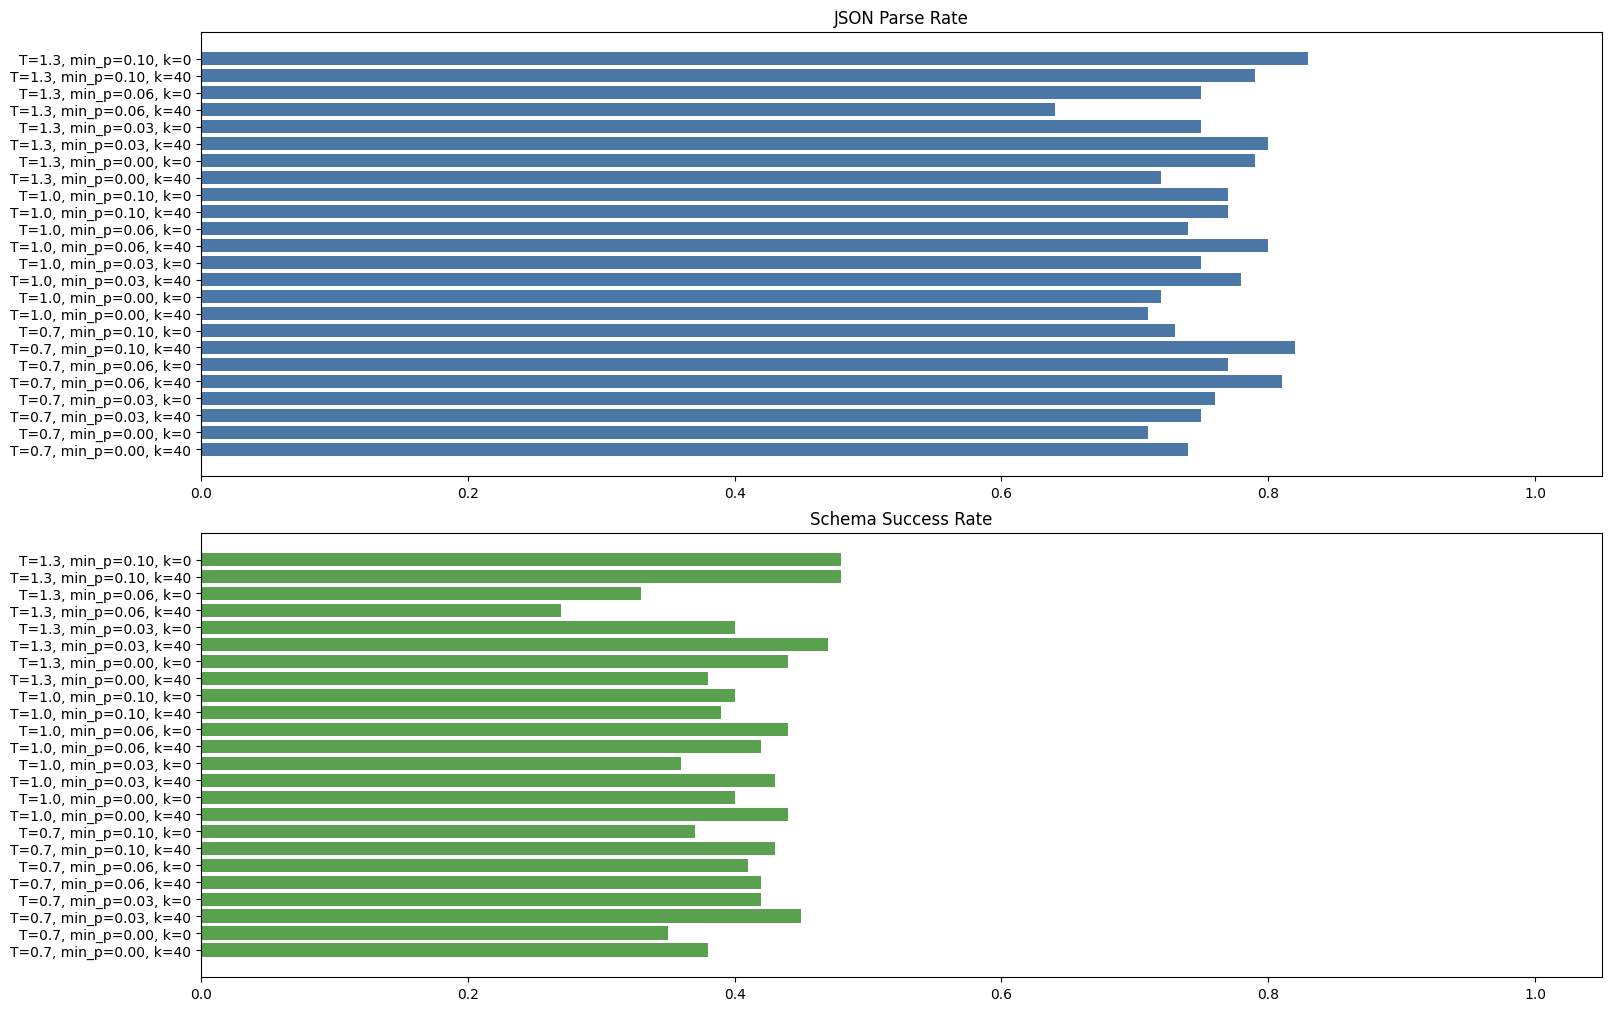

In [11]:
def plot_grouped(summary: pd.DataFrame):
    df = summary.copy()
    df["top_k_label"] = df["top_k"].fillna(0).astype(int).astype(str)
    df["label"] = df.apply(
        lambda r: f"T={r['temperature']}, min_p={r['min_p']:.2f}, k={r['top_k_label']}",
        axis=1
    )
    df = df.sort_values(["temperature", "min_p", "top_k"])

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    axes[0].barh(df["label"], df["json_parse_rate"], color="#4C78A8")
    axes[0].set_xlim(0, 1.05)
    axes[0].set_title("JSON Parse Rate")

    axes[1].barh(df["label"], df["schema_rate"], color="#59A14F")
    axes[1].set_xlim(0, 1.05)
    axes[1].set_title("Schema Success Rate")

    plt.show()

plot_grouped(summary_sorted)


## 7) 실습 과제 (Hands-on)

목표:

1) `temperature=1.6~2.0` 구간에서  
2) JSON 스키마 성공률(`schema_rate`)을 **최소 0.7 이상**으로 올리기  
3) 동시에 `top_p`를 너무 낮추지 말기(예: 0.8 이상 유지)

힌트:
- `min_p`를 0.03~0.15 사이에서 스윕해보세요.
- `top_k`를 같이 쓰면 분산이 줄고, 다만 너무 작게 잡으면 다양성이 급감합니다.


In [12]:
temps = [1.6, 1.8, 2.0]
min_ps = [0.0, 0.03, 0.06, 0.10, 0.14]
top_ks = [None, 40]

results = []
for T in temps:
    for mp in min_ps:
        for tk in top_ks:
            sp_kwargs = dict(
                temperature=T,
                top_p=0.9,
                max_tokens=1024,
            )
            label = f"T{T}_top_p0.9"

            if tk is not None:
                sp_kwargs["top_k"] = tk
                label += f"_top_k{tk}"

            if mp > 0:
                sp_kwargs["min_p"] = mp
                label += f"_dmin_p{mp}"

            sp = make_sampling_params(**sp_kwargs)
            df = sample_many(llm, PROMPT_JSON, sp, label, num_samples=100)

            results.append({
                "preset": label,
                "temperature": T,
                "top_k": tk,
                "min_p": mp,
                "samples": len(df),
                "json_parse_rate": float(df["json_parse_ok"].mean()),
                "schema_rate": float(df["schema_ok"].mean()),
                "avg_len": float(df["len_chars"].mean()),
            })

grid = pd.DataFrame(results)
grid["top_k_sort"] = grid["top_k"].fillna(0)

grid = grid.sort_values(
    ["temperature", "top_k_sort", "min_p"],
    ascending=[True, True, True]
).reset_index(drop=True)

grid


Processed prompts: 100%|██████████| 100/100 [00:09<00:00, 10.63it/s, est. speed input: 3146.69 toks/s, output: 1696.13 toks/s]


,preset,temperature,top_k,min_p,samples,json_parse_rate,schema_rate,avg_len,top_k_sort
0,T1.6_top_p0.9,1.6,NaN,0.00,100,0.77,0.46,271.28,0.0
1,T1.6_top_p0.9_dmin_p0.03,1.6,NaN,0.03,100,0.76,0.39,272.96,0.0
2,T1.6_top_p0.9_dmin_p0.06,1.6,NaN,0.06,100,0.72,0.43,280.10,0.0
3,T1.6_top_p0.9_dmin_p0.1,1.6,NaN,0.10,100,0.77,0.49,273.88,0.0
4,T1.6_top_p0.9_dmin_p0.14,1.6,NaN,0.14,100,0.79,0.46,264.31,0.0
5,T1.6_top_p0.9_top_k40,1.6,40.0,0.00,100,0.78,0.38,280.12,40.0
6,T1.6_top_p0.9_top_k40_dmin_p0.03,1.6,40.0,0.03,100,0.81,0.34,282.84,40.0
7,T1.6_top_p0.9_top_k40_dmin_p0.06,1.6,40.0,0.06,100,0.83,0.44,274.78,40.0
8,T1.6_top_p0.9_top_k40_dmin_p0.1,1.6,40.0,0.10,100,0.77,0.30,267.07,40.0
9,T1.6_top_p0.9_top_k40_dmin_p0.14,1.6,40.0,0.14,100,0.72,0.37,256.37,40.0


## 8) 정리

- high temperature에서 `top_p`만으로는 “아주 낮은 확률 토큰”이 종종 섞이며 출력이 무너질 수 있습니다.
- `min_p`는 이런 토큰을 바닥에서 한 번 더 거르는 역할로,
  특히 **형식/제약이 있는 출력(JSON 등)**에서 로버스트함을 개선할 수 있습니다.

다음 노트북에서는 같은 파라미터를 **vLLM OpenAI 호환 서버**로 보내서
클라이언트-서버 구조에서 재현해봅니다.
